In [4]:
import sys
sys.path.insert(0, '..')


# Basic imports
import jax.numpy as np
import jax.random as jr
import jax.scipy as jsp
import jax
import numpy

jax.config.update("jax_enable_x64", True)


# Optimisation imports
import zodiax as zdx
import optax
import optimistix as optx
import equinox as eqx

# dLux imports
import dLux as dl
import dLux.utils as dlu

#FITS 
from astropy.io import fits
from pathlib import Path
import pandas as pd

# Visualisation imports
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib
import chainconsumer as cc


%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 72
plt.rcParams["font.size"] = 24

from detectors import *
from apertures import *
from models import *
from stats import posterior
from fitting import *
from plotting import *
from spectra import *

import jax.tree_util as jtu
import interpax as ipx

def set_array(pytree):
    dtype = np.float64 if jax.config.x64_enabled else np.float32
    floats, other = eqx.partition(pytree, eqx.is_inexact_array_like)
    floats = jtu.tree_map(lambda x: np.array(x, dtype=dtype), floats)
    return eqx.combine(floats, other)

In [5]:
# Model sizes
wid = 64 
oversample = 4

# extra oversampling used for FFT shifts
psf_oversample = 4

nwavels = 20
npoly = 5
n_zernikes = 20

spectrum_basis = np.ones((nwavels, npoly))


In [6]:
# NICMOS optics and detector

optics = NICMOSOptics(512, wid, oversample)
oversampled_optics = NICMOSOptics(512, wid, oversample*psf_oversample, psf_oversample=psf_oversample)
detector = NICMOSDetector(oversample, wid)


In [7]:
# ddir = Path("../FOSE7902/data/MAST_10143/MAST/HST/")

# rows = []

# for fname_i in sorted(ddir.glob("*_cal.fits")):

#     hdr = fits.getheader(fname_i, ext=0)

#     rows.append({
#         "filename": fname_i.name,
#         "path": fname_i,
#         "target": hdr.get("TARGNAME"),
#         "filter": hdr.get("FILTER"),
#         "exptime": hdr.get("EXPTIME"),
#         "mjd": hdr.get("EXPSTART"),
#         "proposal": hdr.get("PROPOSID"),
#     })

# files_table = pd.DataFrame(rows)

# files_by_filter = {
#     filt: group["path"].tolist()
#     for filt, group in files_table.groupby("filter")
# }

In [8]:
#choose first f170M exposure 
# fname = files_by_filter["F170M"][5]

ddir = '../FOSE7902/data/MAST_10143/MAST/HST/'
#fname = ddir + "n8yj58vjq_cal.fits"

fname = ddir + "n8yj19l6q_cal.fits"
print(fname)

hdr = fits.getheader(fname, ext=0)
filter_name = hdr["FILTER"]

print("Filename:", fname)
print("Target:", hdr["TARGNAME"])
print("Filter:", filter_name)
print("Exposure time:", hdr["EXPTIME"])
print("MJD:", hdr["EXPSTART"])




../FOSE7902/data/MAST_10143/MAST/HST/n8yj19l6q_cal.fits
Filename: ../FOSE7902/data/MAST_10143/MAST/HST/n8yj19l6q_cal.fits
Target: U10617
Filter: F170M
Exposure time: 447.9474
MJD: 53368.565154


In [9]:
exposures_single = [
    exposure_from_file(
        fname,
        SinglePointFit(spectrum_basis, filter_name),
        crop=wid
    )
]

exposures_binary = [
    exposure_from_file(
        fname,
        BinaryFit(spectrum_basis, filter_name),
        crop=wid
    )
]

print(exposures_single[0].data.shape)
print(exposures_single[0].bad.shape)


Version 4.4.1
crop centre: 126 17
Version 4.4.1
crop centre: 126 17
(64, 64)
(64, 64)


In [10]:
params = {
    #"fluxes": {},
    "positions": {},
    "spectrum": {},
    "aberrations": {},
    "cold_mask_shift": {},
    "cold_mask_rot": {},
    "cold_mask_scale": {},
    "cold_mask_shear": {},
    "primary_scale": {},
    "primary_rot": {},
    "primary_shear": {},
    "outer_radius": 1.2*0.955,
    
    "secondary_radius": 0.372*1.2,
    "spider_width": 0.077*1.2,
    "scale": 0.0432,
    "rot": 0.,
    "softening": 2.,
    "bias": {}
}

In [11]:
for exp in exposures_single:
    params["positions"][exp.fit.get_key(exp, "positions")] = np.asarray([0.,0.])
    params["spectrum"][exp.fit.get_key(exp, "spectrum")] = np.zeros(npoly).at[0].set(1)*np.log10(np.nansum(exp.data)/nwavels)
    params["aberrations"][exp.fit.get_key(exp, "aberrations")] = np.zeros(26)
    params["cold_mask_shift"][exp.fit.get_key(exp, "cold_mask_shift")] = -np.asarray([-0.06, -0.06])*1e2
    params["cold_mask_rot"][exp.fit.get_key(exp, "cold_mask_rot")] = -45.
    params["cold_mask_scale"][exp.fit.get_key(exp, "cold_mask_scale")] = np.asarray([1.,1.])
    params["cold_mask_shear"][exp.fit.get_key(exp, "cold_mask_shear")] = np.asarray([0.,0.])
    params["primary_rot"][exp.fit.get_key(exp, "primary_rot")] = -45. #+ 180.
    params["primary_scale"][exp.fit.get_key(exp, "primary_scale")] = np.asarray([1.,1.])
    params["primary_shear"][exp.fit.get_key(exp, "primary_shear")] = np.asarray([0.,0.])

    params["bias"][exp.fit.get_key(exp, "bias")] = 0.

In [12]:
# single source model at normal detector resolution
model_normal = set_array(NICMOSModel(exposures_single, params, optics, detector))

# Same single source model but with much finer PSF sampling 
# This is what we use for the FFT shifting 
model_oversampled = set_array(NICMOSModel(exposures_single, params, oversampled_optics, detector))

#Proper Binary fit version used later for the grid search
model_binary = set_array(NICMOSModel(exposures_binary, params, optics, detector))


params = ModelParams(params)

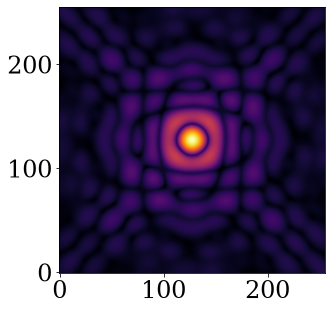

In [13]:
# generate oversampled PSF
# Basically this is the template we about the slide around until it lines up with the actual NICMOS observation
psf = exposures_single[0].fit(model_oversampled,exposures_single[0])
plt.imshow(psf**0.25)

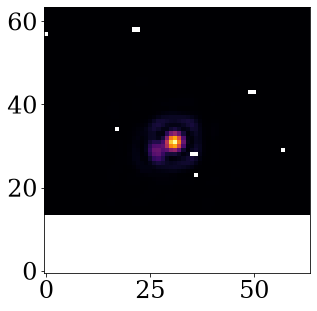

In [14]:
# the actual NICMOS observation
plt.imshow(exposures_single[0].data)
#plt.imshow(exposures_single[0].data)

In [15]:
# Infut the PSF > fourier transform > apply a phase ramp > inverse fourier transform > output the shifted PSF (by dx, dy)
# It can move the PSF by sub pixel amounts 

In [16]:
# Shrish's FFT shifting code
fft, ifft, fftshift = np.fft.fft2, np.fft.ifft2, np.fft.fftshift
rfft, irfft, rfftfreq = np.fft.rfft2, np.fft.irfft2, np.fft.rfftfreq

def reposition(image,dx,dy):
    '''
    Shift an image by dx, dy pixels using FFT

    Parameters
    ----------
    image : ndarray
        2D image to be shifted
    dx : float
        shift in x direction
    dy : float
        shift in y direction
    
    Returns
    -------
    shifted_image : ndarray
        2D image shifted by dx, dy
    
    '''

    # Get the shape of the image
    Nx, Ny = image.shape

    # Create the frequency grid
    kx = fftshift(np.fft.fftfreq(Nx, d=1.))
    ky = fftshift(np.fft.fftfreq(Ny, d=1.))

    # Create the phase ramp
    phase_ramp = np.exp(-2.j*np.pi*(kx[:,None]*dx + ky[None,:]*dy))

    # Shift the image in Fourier space
    shifted_image = fftshift(ifft(fft(fftshift(image))*fftshift(phase_ramp)))

    return np.abs(shifted_image) 

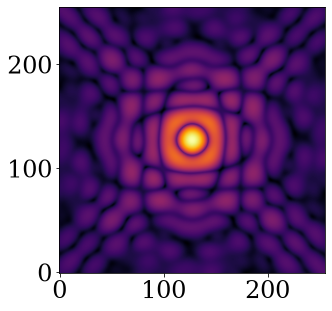

In [17]:
# Snity check to see if the repositioning works and doesn't introduce any unwanted shifts when asked to move by 0.
plt.imshow(reposition(psf, 0, 0)**0.125)

In [18]:
# template is the shifted PSF, flattens the 2D image into one long array 
# ignores the bad detector pixels 
#normalises the psf to have a sum of 1
# it finds the best overall brightness( true_flux) for that PSF 
# it compares the scaled PSF against the real nicmos data using the error values

In [19]:
def fit_flux(exp, template):

    psf = template.flatten()

    bad = exp.bad.flatten()
    err = exp.err.flatten()

    psf= np.where(exp.bad.flatten(), 0., psf)

    psf = psf/np.sum(psf)

    data = exp.data.flatten()
        #data= data.at[exp.bad.flatten()].set(0.)
    data= np.where(exp.bad.flatten(), 0., data)


    design = np.transpose(np.vstack((np.ones(len(psf)), psf)))

    flux_raw, _, _, _ = np.linalg.lstsq(design, data)
    true_flux = flux_raw[1]        
    #true_flux= np.log10(flux_raw[1]/nwavels * 2/(1+contrast)) - spec
        #print(true_flux)
    
    return -np.sum(np.where(bad, 0., jsp.stats.norm.logpdf(psf*true_flux, data, err))), true_flux#loss(template*true_flux, exp)

/var/folders/qm/mthjrl8d16165dq8zlbg2cl00000gn/T/ipykernel_2715/422384232.py:4: RuntimeWarning: invalid value encountered in power
  plt.imshow(data_raw**0.125, origin="lower")


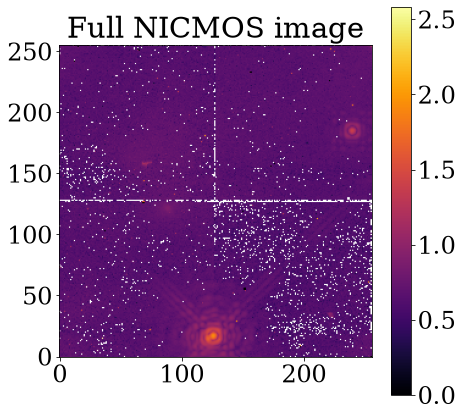

In [20]:
data_raw = fits.getdata(fname, ext=1)

plt.figure(figsize=(7, 7))
plt.imshow(data_raw**0.125, origin="lower")
plt.title("Full NICMOS image")
plt.colorbar()
plt.show()

In [21]:
# dx, dy > shift oversample PSF using FFT > dx , dy  x 4 > then downsample to 64x64 to match the NICMOS observation
# > compare with real NICMOS data > return the loss

In [22]:
@eqx.filter_jit
def grid_loss_single(dx, dy):
    psf_shifted = dlu.downsample(reposition(psf, dx*psf_oversample,dy*psf_oversample), psf_oversample)
    return fit_flux(exposures_single[0], psf_shifted)[0]

In [23]:
# Centroid grid search with 50 possible position in each direction
# so altogether 2500 different PSF positions are tested.
Nx, Ny = 50, 50

xs = np.linspace(-5, 5, Nx)
ys = np.linspace(-5, 5, Ny)

single_losses = np.zeros((Nx, Ny))

for i, dx in enumerate(xs):
    for j, dy in enumerate(ys):
        #print(grid_loss(dx,dy))
        single_losses = single_losses.at[i,j].set(grid_loss_single(dx,dy))
        #psf_shifted = dlu.downsample(reposition(psf, dx*psf_oversample,dy*psf_oversample), psf_oversample)
        #losses = losses.at[i,j].set(fit_flux(exposures_single[0], psf_shifted))

In [24]:
xi, yi = np.unravel_index(single_losses.argmin(), single_losses.shape)
xp, yp = xs[xi], ys[yi]

# Best single-source PSF from the grid result
best_single_psf = dlu.downsample(
    reposition(
        psf,
        xp * psf_oversample,
        yp * psf_oversample
    ),
    psf_oversample
)

# Get the best fitted flux for that PSF
single_loss, single_flux = fit_flux(
    exposures_single[0],
    best_single_psf
)

print("Best x shift:", xp)
print("Best y shift:", yp)
print("Single loss:", single_loss)
print("Single flux:", single_flux)

Best x shift: -0.5102040816326535
Best y shift: -0.7142857142857142
Single loss: 916510.2571845308
Single flux: 4003.0437840771774


In [25]:
def extract_single_params(params, exposures, x, y, flux):
   # Start from the existing parameter dictionary
    param_dict = params.params.copy()

    param_dict["positions"] = dlu.list2dictionary([(exp.fit.get_key(exp, "positions"), np.array([y, x])) for exp in exposures], ordered=True)

    throughput = calc_throughput(exposures_single[0].filter, nwavels=1)[1]

    # Convert best-fit linear flux into the spectrum representation used by the model
    single_spectrum = (np.zeros(npoly).at[0].set(single_flux/nwavels)/throughput)
    param_dict["spectrum"] = dlu.list2dictionary([(exp.fit.get_key(exp, "spectrum") , single_spectrum) for exp in exposures], ordered=True)
   
    #Update source position from grid search
    return ModelParams(param_dict)


In [26]:
single_params = extract_single_params(params, exposures_single, xp, yp, single_flux)
model_single = set_array(NICMOSModel(exposures_single, single_params.params, optics, detector))

In [27]:
# plt.figure(figsize=(7, 6))

# plt.imshow(
#     single_losses.T,
#     origin="lower",
#     extent=[
#         xs.min(),
#         xs.max(),
#         ys.min(),
#         ys.max()
#     ],
#     aspect="auto"
# )

# plt.scatter(
#     xp,
#     yp,
#     marker="x",
#     s=100
# )

# plt.colorbar(label="Loss")

# plt.xlabel("x shift [pixels]")
# plt.ylabel("y shift [pixels]")

# plt.show()

22.430895646921137


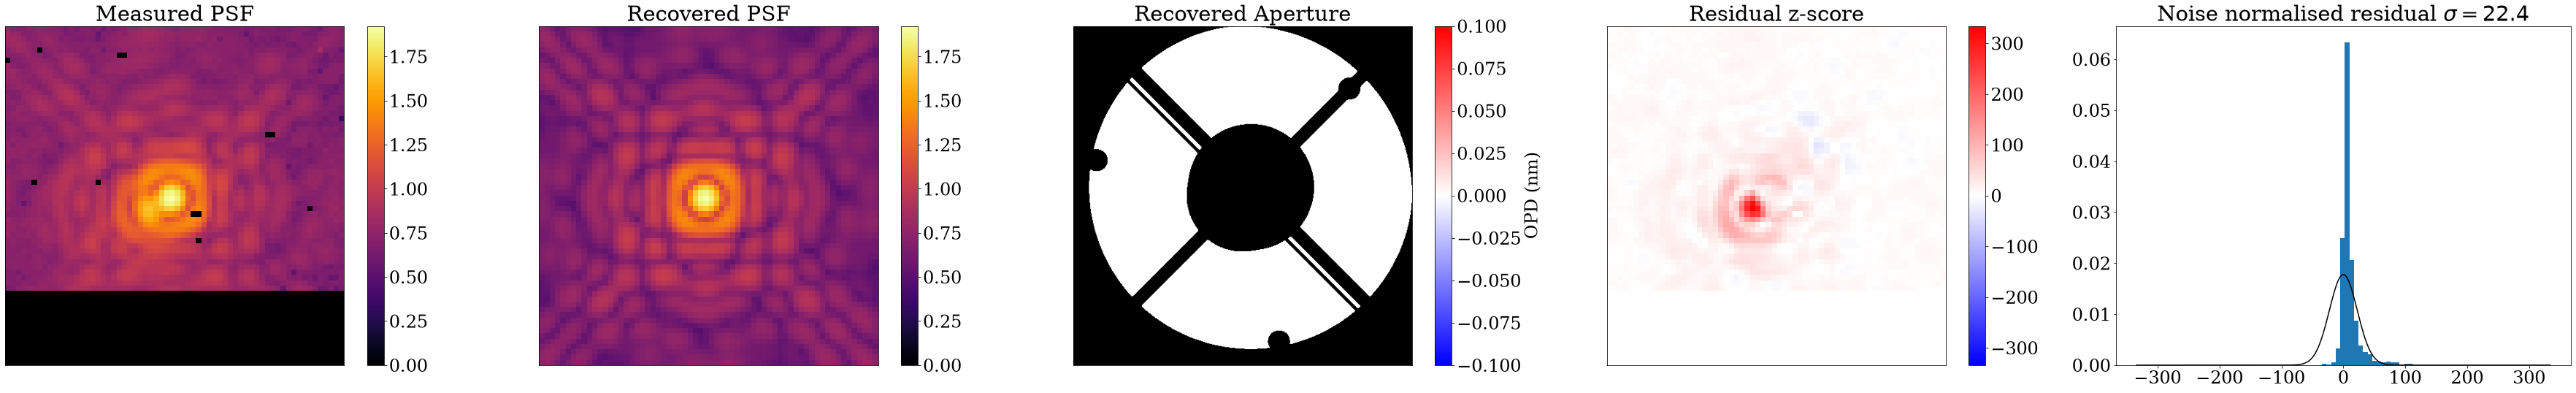

In [28]:
plot_comparison(model_single, single_params, exposures_single)

In [29]:
# so we know primary star is at (xp, yp) and secondary star is at (xp + 0.5, yp + 0.5)

In [30]:
@eqx.filter_jit
def grid_loss_binary(dx1, dy1, r, theta, contrast, return_flux = False, return_psf = False):

    ang = dlu.deg2rad(theta)
    dx2 = dx1-r*np.cos(ang)
    dy2 = dy1-r*np.sin(ang)

    #take the original single star psf and shift it to the primary and secondary star positions
    primary_shifted = reposition(psf, dx1*psf_oversample,dy1*psf_oversample)
    secondary_shifted = reposition(psf, dx2*psf_oversample,dy2*psf_oversample)

    f1, f2 = dlu.fluxes_from_contrast(1, contrast)
    psf_total = dlu.downsample(f1*primary_shifted + f2*secondary_shifted, psf_oversample)
    
    if return_psf:
        return psf_total
    if return_flux:
        return fit_flux(exposures_single[0], psf_total)
    return fit_flux(exposures_single[0], psf_total)[0]

In [31]:
Nx, Ny, Nc = 20, 50, 20

rs = np.linspace(0, 5, Nx)
thetas = np.linspace(-180, 180, Ny)
cs = 10**(np.linspace(0, 1, Nc))
binary_losses = np.zeros((Nx, Ny, Nc))

for i, r in enumerate(rs):
    for j, theta in enumerate(thetas):
        for k, c in enumerate(cs):

            binary_losses = binary_losses.at[i, j, k].set(
                grid_loss_binary(
                    xp,
                    yp,
                    r,
                    theta,
                    c
                )
            )

ri, ti, ci = np.unravel_index(binary_losses.argmin(), binary_losses.shape)

rs, ts, cont = rs[ri], thetas[ti], cs[ci]
print(rs, ts, cont)

4.2105263157894735 62.44897959183672 3.3598182862837818


In [ ]:
best_binary_psf = grid_loss_binary(xp, yp, rs, ts, cont, return_psf=True)
binary_loss, binary_flux =  grid_loss_binary(xp,yp, rs, ts, cont, return_flux=True)



Best x shift: -0.5102040816326535
Best y shift: -0.7142857142857142
Best separation: 4.2105263157894735
Best position angle: 62.44897959183672
Best contrast: 3.3598182862837818
Binary loss: 141906.68347604043
Binary flux: 4909.508503935928


In [33]:
def extract_binary_params(params, exposures, x, y, theta, r, flux, contrast):
    ang = dlu.deg2rad(theta)

    #fluxes = dlu.fluxes_from_contrast(flux, contrast)
    param_dict = params.params.copy()

    # Remove the old single-source spectrum
    param_dict.pop("spectrum", None)


    # param_dict["primary_spectrum"] = param_dict["spectrum"]
    # param_dict["secondary_spectrum"] = param_dict["spectrum"]

    #Split total flux using contrast
    f1, f2 = dlu.fluxes_from_contrast(1., contrast)

    # Convert these into fractions of the TOTAL binary flux
    flux_sum = f1 + f2

    f1 = f1 / flux_sum
    f2 = f2 / flux_sum

    primary_flux = flux * f1
    secondary_flux = flux * f2
    

    throughput = calc_throughput(exposures_binary[0].filter, nwavels=1)[1]


    # Convert the flux into spectra
    primary_spectrum = (np.zeros(npoly).at[0].set(primary_flux/nwavels)) / throughput
    secondary_spectrum = (np.zeros(npoly).at[0].set(secondary_flux/nwavels)) / throughput

    # Update the parameter dictionary with the new spectra
    param_dict["primary_spectrum"] = dlu.list2dictionary([(exp.fit.get_key(exp, "primary_spectrum"), primary_spectrum) for exp in exposures], ordered=True)
    param_dict["secondary_spectrum"] = dlu.list2dictionary([(exp.fit.get_key(exp, "secondary_spectrum"), secondary_spectrum) for exp in exposures], ordered=True)



    #param_dict["contrast"] = dlu.list2dictionary([(exp.fit.get_key(exp, "contrast"), contrast) for exp in exposures], ordered=True) #tree_mul(param_dict["spectrum"], fluxes[1])

    #binary_params = ModelParams(param_dict)

    # # Keep the grid-search contrast explicitly
    # binary_info = {
    #     "contrast": contrast,
    #     "total_flux": flux,
    #     "primary_flux": primary_flux,
    #     "secondary_flux": secondary_flux,
    # }

    param_dict["positions"] = dlu.list2dictionary([(exp.fit.get_key(exp, "positions"), np.array([y-r*np.sin(ang)/2,x-r*np.cos(ang)/2])) for exp in exposures], ordered=True)#np.array([x,y])
    param_dict["separation"] = r#dlu.list2dictionary([(exp.fit.get_key(exp, "separation"), r) for exp in exposures])
    param_dict["position_angle"] = theta#-theta+90 #dlu.list2dictionary([(exp.fit.get_key(exp, "position_angle"), theta) for exp in exposures])
    #return binary_params, binary_info
    return ModelParams(param_dict)

In [34]:
binary_params = extract_binary_params(params, exposures_binary, xp, yp, ts, rs, binary_flux, cont)
model_binary = set_array(NICMOSModel(exposures_binary, binary_params.params, optics, detector))

In [35]:
f1, f2 = dlu.fluxes_from_contrast(1., cont)

f1 = f1 / (f1 + f2)
f2 = 1 - f1

primary_flux = binary_flux * f1
secondary_flux = binary_flux * f2

print("Primary flux:", primary_flux)
print("Secondary flux:", secondary_flux)

print("\nPrimary + secondary:")
print(primary_flux + secondary_flux)

print("Grid binary flux:")
print(binary_flux)

Primary flux: 3783.4275112070573
Secondary flux: 1126.080992728871

Primary + secondary:
4909.508503935928
Grid binary flux:
4909.508503935928


> does this shape produced by 2 overlapping PSF match the observed image better than one PSF? and yes from the loss overlapping does explain better 

9.551339386523685


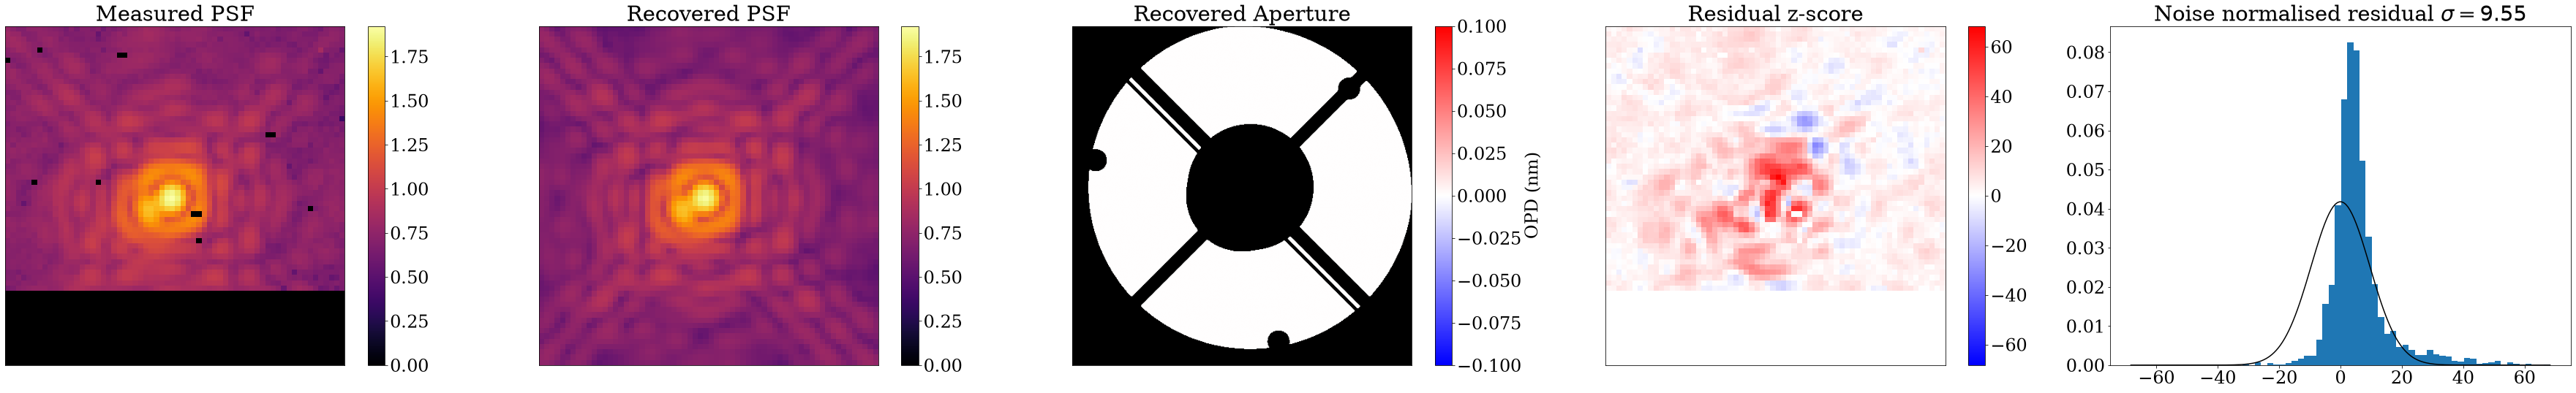

In [36]:
plot_comparison(model_binary, binary_params, exposures_binary)

In [37]:
exp = exposures_single[0]

# ----------------------------------
# Apply bad-pixel mask
# ----------------------------------

single_template = np.where(
    exp.bad,
    0.,
    best_single_psf
)

binary_template = np.where(
    exp.bad,
    0.,
    best_binary_psf
)

# ----------------------------------
# Normalise PSFs
# ----------------------------------

single_template = (
    single_template /
    np.sum(single_template)
)

binary_template = (
    binary_template /
    np.sum(binary_template)
)

# ----------------------------------
# Scale by best-fit flux
# ----------------------------------

single_model = (
    single_template *
    single_flux
)

binary_model = (
    binary_template *
    binary_flux
)

In [38]:

single_z = np.where(
    exp.bad,
    np.nan,
    (exp.data - single_model) / exp.err
)

binary_z = np.where(
    exp.bad,
    np.nan,
    (exp.data - binary_model) / exp.err
)

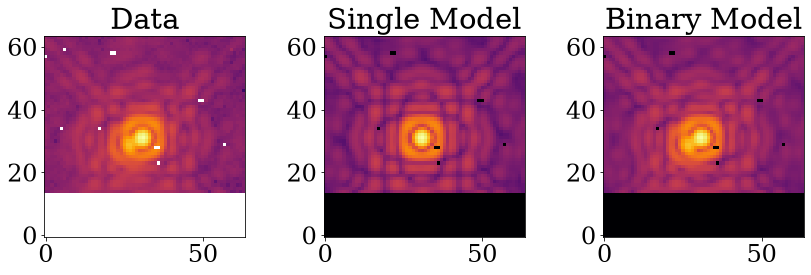

In [39]:
vmin = 0 
vmax = np.nanmax(np.array([exp.data, single_model, binary_model]))**0.125


fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].imshow(exp.data**0.125, vmin=vmin, vmax=vmax)
ax[0].set_title("Data")

ax[1].imshow(single_model**0.125, vmin=vmin, vmax=vmax)
ax[1].set_title("Single Model")

ax[2].imshow(binary_model**0.125, vmin=vmin, vmax=vmax)
ax[2].set_title("Binary Model")

plt.tight_layout()
plt.show()

In [40]:
# the target is close the to detector boundary , s the bottom secion of 64 X64 is cutout and not inclided in the fit 

# Calibration
#### so you do gradient descent then optimise further to L-BFGS

In [41]:
#later add in fitting.py func
def add_calibration_params(source_params,exposures):

    param_dict = source_params.params.copy()

    # Telescope / calibration parameters
    param_dict["aberrations"] = {}
    param_dict["cold_mask_shift"] = {}
    param_dict["cold_mask_rot"] = {}
    param_dict["cold_mask_scale"] = {}
    param_dict["cold_mask_shear"] = {}

    param_dict["primary_scale"] = {}
    param_dict["primary_rot"] = {}
    param_dict["primary_shear"] = {}

    param_dict["defocus"] = {}
    param_dict["despace"] = {}
    param_dict["bias"] = {}
    param_dict["jitter"] = {}
    param_dict["quadrature"] = {}

    # Global telescope parameters
    param_dict["outer_radius"] = 1.2 * 0.955
    param_dict["secondary_radius"] = 0.372 * 1.2
    param_dict["spider_width"] = 0.077 * 1.2

    param_dict["softening"] = 10.
    param_dict["mag"] = 3.3

    for exp in exposures:

        param_dict["aberrations"][
            exp.fit.get_key(exp, "aberrations")
        ] = np.zeros(n_zernikes)

        param_dict["cold_mask_shift"][
            exp.fit.get_key(exp, "cold_mask_shift")
        ] = np.asarray([8., 8.])

        param_dict["cold_mask_rot"][
            exp.fit.get_key(exp, "cold_mask_rot")
        ] = -45.

        param_dict["cold_mask_scale"][
            exp.fit.get_key(exp, "cold_mask_scale")
        ] = np.asarray([1., 1.])

        param_dict["cold_mask_shear"][
            exp.fit.get_key(exp, "cold_mask_shear")
        ] = np.asarray([0., 0.])

        param_dict["primary_rot"][
            exp.fit.get_key(exp, "primary_rot")
        ] = -45. + 90.

        param_dict["primary_scale"][
            exp.fit.get_key(exp, "primary_scale")
        ] = np.asarray([1., 1.])

        param_dict["primary_shear"][
            exp.fit.get_key(exp, "primary_shear")
        ] = np.asarray([0., 0.])

        param_dict["defocus"][
            exp.fit.get_key(exp, "defocus")
        ] = 0.

        param_dict["despace"][
            exp.fit.get_key(exp, "despace")
        ] = 0.

        param_dict["bias"][
            exp.fit.get_key(exp, "bias")
        ] = 0.

        param_dict["jitter"][
            exp.fit.get_key(exp, "jitter")
        ] = 7 / 43 * oversample

        param_dict["quadrature"][
            exp.fit.get_key(exp, "quadrature")
        ] = np.array(0.)

    return ModelParams(param_dict)

In [42]:
# start from the grid result

single_params = extract_single_params(params, exposures_single,xp,yp,single_flux)
binary_params = extract_binary_params(params, exposures_binary,xp,yp,ts,rs, binary_flux,cont)


In [43]:
single_cal_params = add_calibration_params(single_params,exposures_single)
binary_cal_params = add_calibration_params(binary_params,exposures_binary)

In [44]:
# Build the calibration model

wid = 64
oversample = 4

nwavels = 7
npoly=1

n_zernikes = 20

optics = NICMOSSecondaryFresnelOptics(512, wid, oversample, mag=3.3, defocus=0., despace=0., n_zernikes = n_zernikes)

detector = NICMOSDetector(oversample, wid)

spectrum_basis = np.ones((nwavels, npoly))

In [45]:
model_single_cal = set_array(NICMOSModel(exposures_single, single_cal_params.params, optics, detector))
model_binary_cal = set_array(NICMOSModel(exposures_binary, binary_cal_params.params, optics, detector))

## The gradient descent trial

In [43]:
# Gradient descent first

def sgd(lr, delay, momentum=0.5):
    return optax.sgd(zdx.optimisation.delay(lr, delay), momentum=momentum)


g = 5e-2


single_star_params = {
    "positions":       sgd(g * 2.5, 0),
    "spectrum":        sgd(g * 3.0, 10),

    "bias":            sgd(g * 3.0, 20),
    "cold_mask_shift": sgd(g * 10.0, 30),

    "despace":         sgd(g * 10.0, 50),
    "aberrations":     sgd(g * 0.01, 70),

    "mag":             sgd(g * 3.0, 100),
    "cold_mask_shear": sgd(g * 0.5, 100),

}

single_sgd_params = set_array({
    key: single_cal_params.params[key]
    for key in single_cal_params.params
    if key in single_star_params
})

In [ ]:
# Run the gradient descenet

single_sgd_losses, single_sgd_history = optimise_new(
    single_sgd_params,
    model_single_cal,
    exposures_single,
    single_star_params,
    200
)

single_after_sgd = (
    single_cal_params.params |
    single_sgd_history[-1]
)

single_sgd_final = ModelParams(single_after_sgd)


## So this debugging at abberations step

In [ ]:
for i in range(65,76):
    print(f"\nstep {i}")
    print(single_sgd_history[i]["aberrations"])

In [ ]:
for i in range(66, 76):

    current = single_sgd_history[i]["aberrations"]
    previous = single_sgd_history[i - 1]["aberrations"]

    print(f"\nStep {i}")
    print("Loss:", single_sgd_losses[i])

    for key in current.keys():

        change = current[key] - previous[key]

        print(f"  {key}")
        print("  aberrations:", current[key])
        print("  change:     ", change)
        print("  max change: ", np.max(np.abs(change)))

In [ ]:
for i in range(66, 76):

    current = single_sgd_history[i]["aberrations"]
    previous = single_sgd_history[i - 1]["aberrations"]

    for key in current.keys():

        change = current[key] - previous[key]

        print(
            f"Step {i:3d} | "
            f"Loss = {single_sgd_losses[i]:.3e} | "
            f"Max aberration change = {np.max(np.abs(change)):.3e}"
        )

In [ ]:
single_before_sgd = (
    single_cal_params.params |
    single_sgd_history[0]
)

single_sgd_start = ModelParams(single_before_sgd)

plot_comparison(
    model_single_cal,
    single_sgd_start,
    exposures_single
)

In [ ]:
single_after_sgd = (single_cal_params.params | single_sgd_history[-1])
single_sgd_final = ModelParams(single_after_sgd)
plot_comparison(
    model_single_cal,
    single_sgd_final,
    exposures_single
)

In [ ]:
print("Starting loss:", single_sgd_losses[0])
print("Final loss:", single_sgd_losses[-1])

plt.plot(single_sgd_losses[:-1])
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

## debug for the BFGS group 

In [ ]:
import time

In [46]:
single_lbfgs_groups = [
    "positions",
    "spectrum",
    "bias",
    "despace",
    "aberrations",
    "cold_mask_shift",
    "cold_mask_shear",
    "mag",
]

In [47]:
single_lbfgs_params = {
    key: single_cal_params.params[key]
    for key in single_lbfgs_groups
}

## just checking with diff steps when it stops converge

In [ ]:
step_tests = [50, 100, 200, 400, 600, 800, 1000]

results = []

for nsteps in step_tests:

    print(f"\n--- Testing {nsteps} steps ---")

    t0 = time.perf_counter()

    fit = optimise_optimistix(
        single_lbfgs_params,
        model_single_cal,
        exposures_single,
        project=False,
        verbose=False,
        max_steps=nsteps
    )

    runtime = time.perf_counter() - t0

    # Rebuild full parameter set
    full_params = ModelParams(
        single_cal_params.params |
        fit.params
    )

    # Calculate loss
    final_loss = loss_fn(
        full_params,
        exposures_single,
        model_single_cal
    )

    # Check PSF is still valid
    mdl = full_params.inject(model_single_cal)

    exp = exposures_single[0]

    psf = exp.fit(
        mdl,
        exp
    )

    n_nan = int(np.sum(np.isnan(psf)))

    results.append([
        nsteps,
        runtime / 60,
        float(final_loss),
        n_nan
    ])

    print(
        f"Steps = {nsteps:4d} | "
        f"Runtime = {runtime/60:.2f} min | "
        f"Loss = {float(final_loss):.3e} | "
        f"NaN pixels = {n_nan}"
    )

In [ ]:
results = np.array(results)

In [ ]:
plt.figure(figsize=(7, 5))

plt.plot(
    results[:, 0],
    results[:, 2],
    marker="o"
)

plt.xlabel("Maximum L-BFGS steps")
plt.ylabel("Final loss")

plt.show()

In [ ]:
plt.figure(figsize=(7, 5))

plt.plot(
    results[:, 0],
    results[:, 1],
    marker="o"
)

plt.xlabel("Maximum L-BFGS steps")
plt.ylabel("Runtime [minutes]")

plt.show()

### debug for no scaling , manual scaling and , heissan eigen projection

In [48]:
single_scale_params = {
    "positions": {
        key: np.ones_like(value) * 0.1
        for key, value in single_lbfgs_params["positions"].items()
    },

    "spectrum": {
        key: np.ones_like(value) * 50.0
        for key, value in single_lbfgs_params["spectrum"].items()
    },

    "bias": {
        key: np.ones_like(value) * 0.01
        for key, value in single_lbfgs_params["bias"].items()
    },

    "despace": {
        key: np.ones_like(value) * 1.0
        for key, value in single_lbfgs_params["despace"].items()
    },

    "aberrations": {
        key: np.ones_like(value) * 1.0
        for key, value in single_lbfgs_params["aberrations"].items()
    },

    "cold_mask_shift": {
        key: np.ones_like(value) * 0.1
        for key, value in single_lbfgs_params["cold_mask_shift"].items()
    },

    "cold_mask_shear": {
        key: np.ones_like(value) * 0.01
        for key, value in single_lbfgs_params["cold_mask_shear"].items()
    },

    "mag": np.asarray(0.1)
}

In [53]:
step_tests = [50, 100,200,400,600,800,1000]

methods = {
    "No scaling": {
        "project": False,
        "scales": None
    },

    "Manual scaling": {
        "project": False,
        "scales": single_scale_params
    },

    # "Hessian projection": {
    #     "project": True,
    #     "scales": None
    # }
}

In [54]:
import time 

all_results = {}

for method_name, settings in methods.items():

    print(f"\n==============================")
    print(f"{method_name}")
    print(f"==============================")

    method_results = []

    for nsteps in step_tests:

        print(f"\n--- Testing {nsteps} steps ---")

        t0 = time.perf_counter()

        fit = optimise_optimistix(
            single_lbfgs_params,
            model_single_cal,
            exposures_single,
            project=settings["project"],
            scales=settings["scales"],
            verbose=False,
            max_steps=nsteps
        )

        runtime = time.perf_counter() - t0

        # Rebuild complete parameter set
        full_params = ModelParams(
            single_cal_params.params |
            fit.params
        )

        # Final loss
        final_loss = loss_fn(
            full_params,
            exposures_single,
            model_single_cal
        )

        # Generate PSF
        mdl = full_params.inject(
            model_single_cal
        )

        exp = exposures_single[0]

        psf = exp.fit(
            mdl,
            exp
        )

        # Check validity
        n_nan = int(
            np.sum(np.isnan(psf))
        )

        n_inf = int(
            np.sum(np.isinf(psf))
        )

        method_results.append([
            nsteps,
            runtime / 60,
            float(final_loss),
            n_nan,
            n_inf
        ])

        print(
            f"Steps = {nsteps:4d} | "
            f"Runtime = {runtime/60:.2f} min | "
            f"Loss = {float(final_loss):.3e} | "
            f"NaNs = {n_nan} | "
            f"Infs = {n_inf}"
        )

    all_results[method_name] = np.array(
        method_results
    )


No scaling

--- Testing 50 steps ---
Steps =   50 | Runtime = 0.21 min | Loss = 8.135e+05 | NaNs = 0 | Infs = 0

--- Testing 100 steps ---
Steps =  100 | Runtime = 0.55 min | Loss = 5.594e+05 | NaNs = 0 | Infs = 0

--- Testing 200 steps ---
Steps =  200 | Runtime = 1.32 min | Loss = 5.278e+05 | NaNs = 0 | Infs = 0

--- Testing 400 steps ---
Steps =  400 | Runtime = 3.47 min | Loss = 4.860e+05 | NaNs = 0 | Infs = 0

--- Testing 600 steps ---
Steps =  600 | Runtime = 4.89 min | Loss = 4.691e+05 | NaNs = 0 | Infs = 0

--- Testing 800 steps ---
Steps =  800 | Runtime = 6.91 min | Loss = 4.561e+05 | NaNs = 0 | Infs = 0

--- Testing 1000 steps ---
Steps = 1000 | Runtime = 9.70 min | Loss = 4.506e+05 | NaNs = 0 | Infs = 0

Manual scaling

--- Testing 50 steps ---
Steps =   50 | Runtime = 0.45 min | Loss = 5.055e+05 | NaNs = 0 | Infs = 0

--- Testing 100 steps ---
Steps =  100 | Runtime = 1.00 min | Loss = 4.657e+05 | NaNs = 0 | Infs = 0

--- Testing 200 steps ---
Steps =  200 | Runtime = 2.0

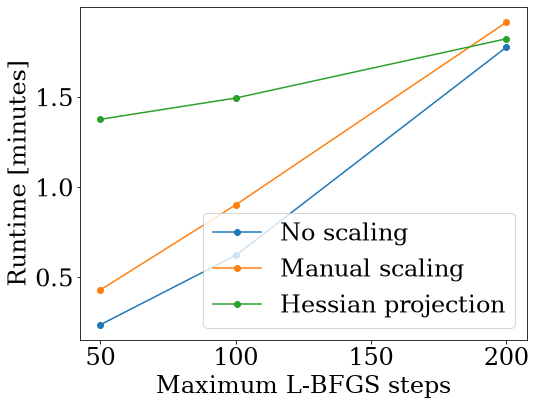

In [51]:
plt.figure(figsize=(8, 6))

for method_name, results in all_results.items():

    plt.plot(
        results[:, 0],
        results[:, 1],
        marker="o",
        label=method_name
    )

plt.xlabel("Maximum L-BFGS steps")
plt.ylabel("Runtime [minutes]")
plt.legend()

plt.show()

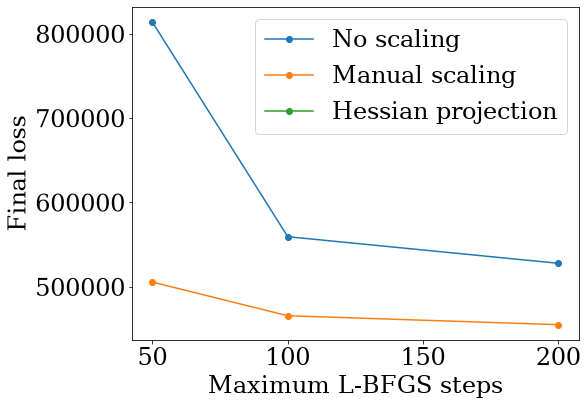

In [52]:
plt.figure(figsize=(8, 6))

for method_name, results in all_results.items():

    plt.plot(
        results[:, 0],
        results[:, 2],
        marker="o",
        label=method_name
    )

plt.xlabel("Maximum L-BFGS steps")
plt.ylabel("Final loss")
plt.legend()

plt.show()

In [ ]:
!pip install celluloid 

In [ ]:
from celluloid import Camera

fig =plt.figure()

camera = Camera(fig)

nsteps = len(single_bfgs_fit)

for j in tqdm(range(nsteps)):
    

In [ ]:

from celluloid import Camera

fig = plt.figure()

camera = Camera(fig)

nsteps = len(single_sgd_history)
for j in tqdm(range(nsteps)):
    single_state= (
        single_cal_params.params |
        single_sgd_history[j]
    )

    single_sgd_state = ModelParams(single_state)
    plot_comparison(
        model_single_cal,
        single_sgd_state,
        exposures_single
    )

    camera.snap()

animation = camera.animate()

# from IPython.display import HTML
# HTML(animation.to_html5_video())


In [ ]:
groups = list(single_star_params.keys())

# paths = flatten(groups)
# optimisers = [things[i] for i in groups]
groups = [list(x) if isinstance(x, tuple) else x for x in groups]

plot_params(single_sgd_history, groups, xw = 3)


In [ ]:
nsteps = len(single_sgd_history)

for param in single_cal_params.params:
       curve = np.array([single_sgd_history[step][param]['n8yj19l6q'] for step in range(nsteps)])

In [ ]:
np.array([single_sgd_history[step][param]['n8yj19l6q'] for step in range(nsteps)])

In [ ]:
single_sgd_history

In [ ]:
binary_things = {
    # Binary source
    "positions":          sgd(g * 5.0, 0),
    "separation":         sgd(g * 0.2, 0),
    "position_angle":     sgd(g * 0.2, 0),

    # Component brightnesses
    "primary_spectrum":   sgd(g * 0.2, 10),
    "secondary_spectrum": sgd(g * 0.2, 10),

    # Detector / telescope
    "bias":               sgd(g * 0.2, 20),

    "cold_mask_shift":    sgd(g * 0.2, 30),

    "despace":            sgd(g * 0.2, 50),

    "aberrations":        sgd(g * 0.2, 70),

    "mag":                sgd(g * 0.1, 100),
    "cold_mask_shear":    sgd(g * 0.1, 100),
}

binary_sgd_params = set_array({
    key: binary_cal_params.params[key]
    for key in binary_cal_params.params
    if key in binary_things
})

binary_sgd_losses, binary_sgd_history = optimise_new(
    binary_sgd_params,
    model_binary_cal,
    exposures_binary,
    binary_things,
    200
)
print("Starting loss:", binary_sgd_losses[0])
print("Final loss:", binary_sgd_losses[-1])

plt.plot(binary_sgd_losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

binary_after_sgd = ModelParams(
    binary_cal_params.params |
    binary_sgd_history[-1]
)

binary_sgd_final = ModelParams(binary_after_sgd)

In [ ]:
plot_comparison(
    model_binary_cal,
    binary_sgd_final,
    exposures_binary
)

In [ ]:
import jax.numpy as np
import jax.random as jr

import numpyro as npy
import numpyro.distributions as dist

from numpyro.infer import MCMC, NUTS
from numpyro.infer.initialization import init_to_value

In [ ]:
# Single HMC 

In [ ]:
exp_single = exposures_single[0]

single_pos_key = exp_single.fit.get_key(
    exp_single,
    "positions"
)

single_spec_key = exp_single.fit.get_key(
    exp_single,
    "spectrum"
)

single_pos0 = single_after_sgd[
    "positions"
][single_pos_key]

single_spec0 = single_after_sgd[
    "spectrum"
][single_spec_key]

print("Single starting position:", single_pos0)
print("Single starting spectrum:", single_spec0)
print("Spectrum shape:", single_spec0.shape)

In [ ]:
def single_hmc_model():

    position = numpyro.sample(
        "position",
        dist.Normal(
            single_pos0,
            jnp.array([0.5, 0.5])
        ).to_event(1)
    )

    spectrum = numpyro.sample(
        "spectrum",
        dist.Normal(
            single_spec0,
            0.2 * jnp.abs(single_spec0) + 1e-3
        ).to_event(1)
    )

    hmc_dict = single_after_sgd.copy()

    hmc_dict["positions"] = {
        **hmc_dict["positions"],
        single_pos_key: position
    }

    hmc_dict["spectrum"] = {
        **hmc_dict["spectrum"],
        single_spec_key: spectrum
    }

    hmc_params = ModelParams(hmc_dict)

    log_likelihood = -loss_fn(
        hmc_params,
        exposures_single,
        model_single_cal
    )

    numpyro.factor(
        "image_likelihood",
        log_likelihood
    )

In [ ]:
single_init_values = {
    "position": single_pos0,
    "spectrum": single_spec0,
}

single_kernel = NUTS(
    single_hmc_model,
    init_strategy=init_to_value(
        values=single_init_values
    ),
    target_accept_prob=0.9
)

single_mcmc = MCMC(
    single_kernel,
    num_warmup=100,
    num_samples=100,
    num_chains=1,
    progress_bar=True
)

single_mcmc.run(
    jr.PRNGKey(43)
)

single_mcmc.print_summary()

single_samples = single_mcmc.get_samples()

### Binary hmc

In [ ]:
exp = exposures_binary[0]

pos_key = exp.fit.get_key(exp, "positions")
primary_spec_key = exp.fit.get_key(exp, "primary_spectrum")
secondary_spec_key = exp.fit.get_key(exp, "secondary_spectrum")

pos0 = binary_after_sgd["positions"][pos_key]
sep0 = binary_after_sgd["separation"]
pa0 = binary_after_sgd["position_angle"]

pflux0 = binary_after_sgd["primary_spectrum"][primary_spec_key]
sflux0 = binary_after_sgd["secondary_spectrum"][secondary_spec_key]

print("Position:", pos0)
print("Separation:", sep0)
print("PA:", pa0)
print("Primary spectrum:", pflux0)
print("Secondary spectrum:", sflux0)

In [ ]:
def binary_hmc_model():

   
    # Source parameters

    y = npy.sample(
        "y",
        dist.Uniform(pos0[0] - 0.5, pos0[0] + 0.5)
    )

    x = npy.sample(
        "x",
        dist.Uniform(pos0[1] - 0.5, pos0[1] + 0.5)
    )

    separation = npy.sample(
        "separation",
        dist.Uniform(
            np.maximum(0.01, sep0 - 1.0),
            sep0 + 1.0
        )
    )

    position_angle = npy.sample(
        "position_angle",
        dist.Uniform(
            pa0 - 20.0,
            pa0 + 20.0
        )
    )

    primary_spectrum = npy.sample(
        "primary_spectrum",
        dist.Normal(
            pflux0,
            0.2 * np.abs(pflux0) + 1e-3
        ).to_event(1)
    )

    secondary_spectrum = npy.sample(
        "secondary_spectrum",
        dist.Normal(
            sflux0,
            0.2 * np.abs(sflux0) + 1e-3
        ).to_event(1)
    )

    
    # Insert into SGD solution
    
    hmc_dict = binary_after_sgd.copy()

    hmc_dict["positions"] = {
        **hmc_dict["positions"],
        pos_key: np.array([y, x])
    }

    hmc_dict["separation"] = separation
    hmc_dict["position_angle"] = position_angle

    hmc_dict["primary_spectrum"] = {
        **hmc_dict["primary_spectrum"],
        primary_spec_key: primary_spectrum
    }

    hmc_dict["secondary_spectrum"] = {
        **hmc_dict["secondary_spectrum"],
        secondary_spec_key: secondary_spectrum
    }

    params = ModelParams(hmc_dict)

    # Existing NICMOS likelihood
    loglike = -loss_fn(
        params,
        exposures_binary,
        model_binary_cal
    )

    npy.factor(
        "image_likelihood",
        loglike
    )

In [ ]:
init_values = {
    "y": pos0[0],
    "x": pos0[1],
    "separation": sep0,
    "position_angle": pa0,
    "primary_spectrum": pflux0,
    "secondary_spectrum": sflux0,
}

kernel = NUTS(
    binary_hmc_model,
    init_strategy=init_to_value(
        values=init_values
    ),
    target_accept_prob=0.9
)

sampler = MCMC(
    kernel,
    num_warmup=200,
    num_samples=300,
    num_chains=1,
    progress_bar=True
)

sampler.run(
    jr.PRNGKey(42)
)

sampler.print_summary()    

extra = sampler.get_extra_fields()

print(
    "Number of divergences:",
    int(extra["diverging"].sum())
)

In [ ]:
# plotting for binary hmc

In [ ]:
import chainconsumer as cc
from chainconsumer import PlotConfig

chain = cc.Chain.from_numpyro(
    sampler,
    "Binary NICMOS",
    color="teal",
    shade_alpha=0.2
)

consumer = (
    cc.ChainConsumer()
    .add_chain(chain)
)

consumer.set_plot_config(
    PlotConfig(
        serif=True,
        spacing=1.0,
        max_ticks=3
    )
)

fig = consumer.plotter.plot()

fig.set_size_inches((15, 15))

plt.show()

In [ ]:
# 1. Get the posterior samples from HMC

binary_samples = sampler.get_samples()

print(binary_samples.keys())

In [ ]:

# 2. Calculate posterior median parameters

binary_median_position = np.array([
    np.median(binary_samples["y"]),
    np.median(binary_samples["x"])
])

binary_median_sep = np.median(
    binary_samples["separation"]
)

binary_median_pa = np.median(
    binary_samples["position_angle"]
)

binary_median_primary = np.median(
    binary_samples["primary_spectrum"],
    axis=0
)

binary_median_secondary = np.median(
    binary_samples["secondary_spectrum"],
    axis=0
)

print("Posterior median position:")
print(binary_median_position)

print("\nPosterior median separation:")
print(binary_median_sep)

print("\nPosterior median PA:")
print(binary_median_pa)

print("\nPosterior median primary spectrum:")
print(binary_median_primary)

print("\nPosterior median secondary spectrum:")
print(binary_median_secondary)

In [ ]:

# 3. Build model using the HMC posterior medians

binary_hmc_median_dict = binary_after_sgd.copy()

binary_hmc_median_dict["positions"] = {
    **binary_hmc_median_dict["positions"],
    pos_key: binary_median_position
}

binary_hmc_median_dict["separation"] = (
    binary_median_sep
)

binary_hmc_median_dict["position_angle"] = (
    binary_median_pa
)

binary_hmc_median_dict["primary_spectrum"] = {
    **binary_hmc_median_dict["primary_spectrum"],
    primary_spec_key: binary_median_primary
}

binary_hmc_median_dict["secondary_spectrum"] = {
    **binary_hmc_median_dict["secondary_spectrum"],
    secondary_spec_key: binary_median_secondary
}

binary_hmc_median = ModelParams(
    binary_hmc_median_dict
)

In [ ]:
plot_comparison(
    model_binary_cal,
    binary_hmc_median,
    exposures_binary
)